In [9]:

from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries imported successfully")

All libraries imported successfully!


In [8]:

df = pd.read_csv('iris.csv')
print(" Dataset loaded Shape:", df.shape)
print(df.head())

print("\nMissing values:\n", df.isnull().sum())

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
print("\n Species encoded successfully!")

X = df.drop('species', axis=1)
y = df['species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Preprocessing Done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

 Dataset loaded Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

 Species encoded successfully!

 Preprocessing Done!
Training samples: 120
Testing samples : 30


K | Accuracy
--------------------
1 | 0.9667
3 | 0.9333
5 | 0.9333
7 | 0.9667
9 | 0.9667

 Best K = 1 with accuracy = 0.9667


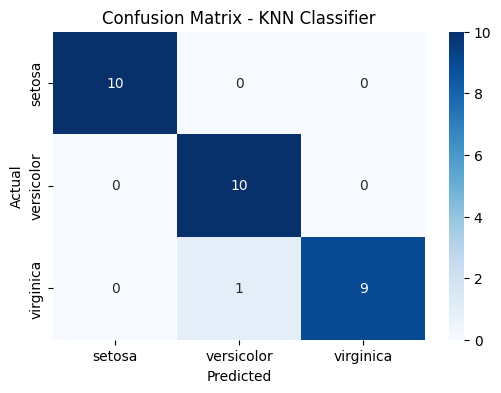


 Final Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [10]:

k_values = [1, 3, 5, 7, 9]
accuracies = []

print("K | Accuracy")
print("-" * 20)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{k} | {acc:.4f}")

best_k = k_values[accuracies.index(max(accuracies))]
print(f"\n Best K = {best_k} with accuracy = {max(accuracies):.4f}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred_final = knn_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n Final Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))
